                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                   32
Model:                            GLM   Df Residuals:                       30
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18.630
Date:                Fri, 16 Jan 2026   Deviance:                       37.259
Time:                        10:21:05   Pearson chi2:                     31.2
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1702
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9418      0.830     -2.340      0.0

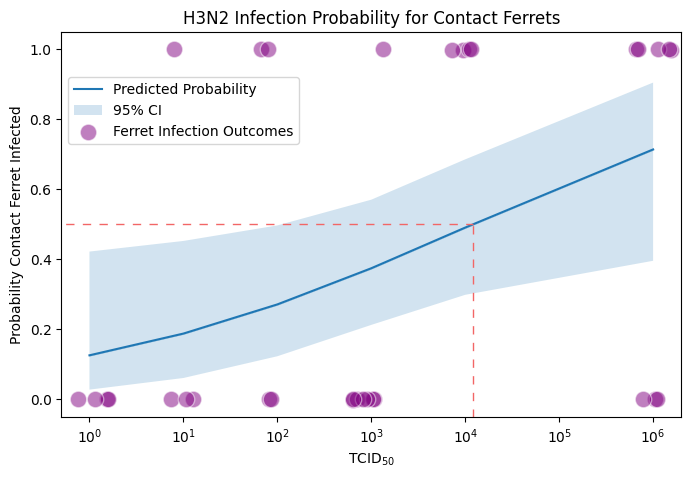

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns





# ### ### ### --- --- --- H3 DATA
# ### ### ### --- --- --- H3 DATA
# ### ### ### --- --- --- H3 DATA
# ### ### ### --- --- --- H3 DATA




# H3 data - the outcome is a successful transmission ("1") or no transmission ("0")
# the dose is in log10 units
df_H3 = pd.DataFrame({
    'outcome': [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    'dose': [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 6, 6]
})

# Define X and y for the logistic regression
X = sm.add_constant(df_H3[['dose']])
y = df_H3['outcome']

# Use GLM instead of Logit
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

# Get predictions with CI
pred = model.get_prediction(X)
summary_frame = pred.summary_frame(alpha=0.05)

# Add predictions to DataFrame
df_H3['predicted_prob'] = summary_frame['mean']
df_H3['ci_lower'] = summary_frame['mean_ci_lower']
df_H3['ci_upper'] = summary_frame['mean_ci_upper']

# Plot
df_H3_sorted = df_H3.sort_values('dose')
plt.figure(figsize=(8, 5))
sns.lineplot(x='dose', y='predicted_prob', data=df_H3_sorted, label='Predicted Probability')
plt.fill_between(df_H3_sorted['dose'], df_H3_sorted['ci_lower'], df_H3_sorted['ci_upper'], alpha=0.2, label='95% CI')

# jitter the actual data points so that multiple overlapping data points can be seen
df_H3_sorted['outcome_jittered'] = df_H3_sorted['outcome'] + np.random.uniform(-0.001, 0.001, size=len(df_H3_sorted))
df_H3_sorted['dose_jittered'] = df_H3_sorted['dose'] + np.random.uniform(-0.2, 0.2, size=len(df_H3_sorted))

# plot the individual data points
sns.scatterplot(x='dose_jittered', y='outcome_jittered', data=df_H3_sorted, color='purple', s=140, alpha=0.5, label='Ferret Infection Outcomes')
plt.xlabel(r'$\mathrm{TCID}_{50}$')
plt.ylabel('Probability Contact Ferret Infected')
plt.title('H3N2 Infection Probability for Contact Ferrets')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 0.9))
plt.ylim(-0.05, 1.05)
plt.xlim(-0.3, 6.3)
plt.xticks([0, 1, 2, 3, 4, 5, 6], [r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$'])
mylightred = (.95, .4, .4)

# plot the lines showing the transmissible-dose-50 (manually done here)
myline,  = plt.plot([4.0808,4.0808], [-0.1, 0.50], color=mylightred, linestyle='--', linewidth=1)
myline2, = plt.plot([-1,4.0808], [0.50, 0.50], color=mylightred, linestyle='--', linewidth=1)
myline.set_dashes([6, 6]) 
myline2.set_dashes([6, 6]) 
plt.savefig('H3_logistic_regression_v2.pdf', format='pdf', dpi=300)
plt.show()



In [2]:
# Extract coefficients
beta0 = model.params['const']
beta1 = model.params['dose']

# Compute ID50
log10_TD50 = -beta0 / beta1
TD50 = 10 ** log10_TD50

print(f"log10(TD50): {log10_TD50:.4f}")
print(f"Estimated TD50: {TD50:.4f}")




log10(TD50): 4.0808
Estimated TD50: 12044.2508


In [3]:
# Step 3: Get covariance matrix of coefficients
cov = model.cov_params()

# Step 4: Delta method for variance of log10(TD50)
# f = -beta0 / beta1, so use partial derivatives
df_dbeta0 = -1 / beta1
df_dbeta1 = beta0 / (beta1**2)

# Variance of f = g(beta0, beta1)
var_f = (
    df_dbeta0**2 * cov.loc['const', 'const'] +
    df_dbeta1**2 * cov.loc['dose', 'dose'] +
    2 * df_dbeta0 * df_dbeta1 * cov.loc['const', 'dose']
)

# Step 5: Compute CI for log10(TD50)
log10_TD50 = -beta0 / beta1
se_log10_TD50 = np.sqrt(var_f)

z = 1.96  # for 95% CI
log10_TD50_lower = log10_TD50 - z * se_log10_TD50
log10_TD50_upper = log10_TD50 + z * se_log10_TD50

# Step 6: Convert to TD50 (original scale)
TD50 = 10 ** log10_TD50
TD50_lower = 10 ** log10_TD50_lower
TD50_upper = 10 ** log10_TD50_upper

# Step 7: Print results
print(f"log10(TD50): {log10_TD50:.4f} [{log10_TD50_lower:.4f}, {log10_TD50_upper:.4f}]")
print(f"ID50: {TD50:.4f} [{TD50_lower:.4f}, {TD50_upper:.4f}]")




log10(TD50): 4.0808 [2.3410, 5.8206]
ID50: 12044.2508 [219.2727, 661568.6836]


In [4]:

# ### ### ### --- --- --- H1 DATA
# ### ### ### --- --- --- H1 DATA
# ### ### ### --- --- --- H1 DATA
# ### ### ### --- --- --- H1 DATA

                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                   24
Model:                            GLM   Df Residuals:                       22
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2.2493
Date:                Fri, 16 Jan 2026   Deviance:                       4.4987
Time:                        10:21:05   Pearson chi2:                     4.00
No. Iterations:                    24   Pseudo R-squ. (CS):             0.1470
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0986      1.155      0.951      0.3

/home/maciek/.local/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


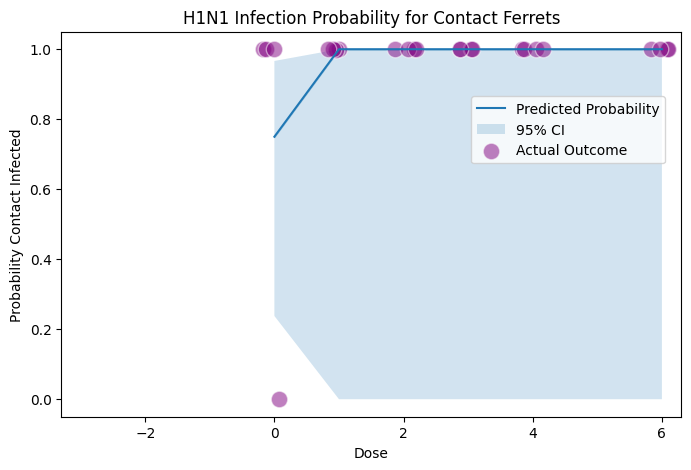

In [5]:
# H1 data

#
# ORIGINAL DATA
#
df_H1 = pd.DataFrame({
    'outcome': [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'dose': [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 6, 6]
})




# here we add one experiment at dose = -1
#df_H1 = pd.DataFrame({
#    'outcome': [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
#    'dose': [-1, -1, -1, -1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 6, 6]
#})


# here we add one experiment at dose = -1 and another experiment at dose = -2
#df_H1 = pd.DataFrame({
#    'outcome': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
#    'dose': [-2, -2, -2, -2, -1, -1, -1, -1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 6, 6]
#})



# here we add one experiment at dose = -1 and another experiment at dose = -2 and another at dose = -3
#df_H1 = pd.DataFrame({
#    'outcome': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
#    'dose': [-3, -3, -3, -3, -2, -2, -2, -2, -1, -1, -1, -1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 6, 6, 6, 6]
#})




# Define X and y
X = sm.add_constant(df_H1[['dose']])
y = df_H1['outcome']

# Use GLM instead of Logit
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

# Get predictions with CI
pred = model.get_prediction(X)
summary_frame = pred.summary_frame(alpha=0.05)

# Add predictions to DataFrame
df_H1['predicted_prob'] = summary_frame['mean']
df_H1['ci_lower'] = summary_frame['mean_ci_lower']
df_H1['ci_upper'] = summary_frame['mean_ci_upper']

# Plot
df_H1_sorted = df_H1.sort_values('dose')
plt.figure(figsize=(8, 5))
sns.lineplot(x='dose', y='predicted_prob', data=df_H1_sorted, label='Predicted Probability')
plt.fill_between(df_H1_sorted['dose'], df_H1_sorted['ci_lower'], df_H1_sorted['ci_upper'], alpha=0.2, label='95% CI')

df_H1_sorted['outcome_jittered'] = df_H1_sorted['outcome'] + np.random.uniform(-0.001, 0.001, size=len(df_H1_sorted))
df_H1_sorted['dose_jittered'] = df_H1_sorted['dose'] + np.random.uniform(-0.2, 0.2, size=len(df_H1_sorted))

sns.scatterplot(x='dose_jittered', y='outcome_jittered', data=df_H1_sorted, color='purple', s=140, alpha=0.5, label='Actual Outcome')
plt.xlabel('Dose')
plt.ylabel('Probability Contact Infected')
plt.title('H1N1 Infection Probability for Contact Ferrets')
plt.legend(loc='upper left', bbox_to_anchor=(0.65, 0.85))
plt.ylim(-0.05, 1.05)
plt.xlim(-3.3, 6.3)
mylightred = (.95, .4, .4)
#myline,  = plt.plot([4.0808,4.0808], [-0.1, 0.50], color=mylightred, linestyle='--', linewidth=1)
#myline2, = plt.plot([-1,4.0808], [0.50, 0.50], color=mylightred, linestyle='--', linewidth=1)
#myline.set_dashes([6, 6]) 
#myline2.set_dashes([6, 6]) 
plt.show()

In [6]:
# Extract coefficients
beta0 = model.params['const']
beta1 = model.params['dose']

# Compute TD50
log10_TD50 = -beta0 / beta1
TD50 = 10 ** log10_TD50

print(f"log10(TD50): {log10_TD50:.4f}")
print(f"Estimated TD50: {TD50:.4f}")

log10(TD50): -0.0525
Estimated TD50: 0.8861


In [7]:
# Step 3: Get covariance matrix of coefficients
cov = model.cov_params()

# Step 4: Delta method for variance of log10(ID50)
# f = -beta0 / beta1, so use partial derivatives
df_dbeta0 = -1 / beta1
df_dbeta1 = beta0 / (beta1**2)

# Variance of f = g(beta0, beta1)
var_f = (
    df_dbeta0**2 * cov.loc['const', 'const'] +
    df_dbeta1**2 * cov.loc['dose', 'dose'] +
    2 * df_dbeta0 * df_dbeta1 * cov.loc['const', 'dose']
)

# Step 5: Compute CI for log10(TD50)
log10_TD50 = -beta0 / beta1
se_log10_TD50 = np.sqrt(var_f)

z = 1.96  # for 95% CI
log10_TD50_lower = log10_TD50 - z * se_log10_TD50
log10_TD50_upper = log10_TD50 + z * se_log10_TD50

# Step 6: Convert to TD50 (original scale)
TD50 = 10 ** log10_TD50
TD50_lower = 10 ** log10_TD50_lower
TD50_upper = 10 ** log10_TD50_upper

# Step 7: Print results
print(f"log10(TD50): {log10_TD50:.4f} [{log10_TD50_lower:.4f}, {log10_TD50_upper:.4f}]")
print(f"TD50: {TD50:.4f} [{TD50_lower:.4f}, {TD50_upper:.4f}]")




log10(TD50): -0.0525 [-90.1265, 90.0215]
TD50: 0.8861 [0.0000, 1050714470414136220628537491187026011085082645037345554890174611340199890898305986148171776.0000]
